# Neural Networks in DSGE мmodelling

The problem taken from Maliar, L., S. Maliar, and P. Winant (2021): “Deep Learning for Solving Dynamic
Economic Models,” Journal of Monetary Economics, 122, 76–101.

## 1. The maximization problem

$$
\max_{\{c_t,\ k_{t+1},\ h_t,\ x_t\}}
E_0 \sum_{t=0}^{\infty} \beta^t u_t(c_t, h_t)
$$

s.t.:


\begin{aligned}
u_t &= \eta \ln c_t + (1-\eta)\ln(1-h_t) \\
y_t &= a_t k_t^{\alpha} h_t^{1-\alpha}, \\
y_t &= c_t + x_t, \\
k_{t+1} &= (1-\delta)k_t + x_t, \\
\ln a_t &= \rho \ln a_{t-1} + \varepsilon_t.
\end{aligned}


$\beta\in(0, 1), \ \eta\in(0, 1) \ \alpha\in(0, 1), \ \delta\in(0, 1), \ \rho\in(0, 1), \ \varepsilon_t\sim N(0, \sigma^2), \ (a_t)$ — exogenous productivity shock.

In order to formulate the deep learning problem we need to derive the FOC's.

---

## 2. Rearranging conditions

Here we plug conditions into the objective function.
From (2) и (3):

$$
x_t = y_t - c_t = a_t k_t^{\alpha} h_t^{1-\alpha} - c_t,
$$
$$
k_{t+1} = (1-\delta)k_t + a_t k_t^{\alpha} h_t^{1-\alpha} - c_t.
$$

---

## 3. Lagrangian

$$\mathcal{L} = E_0 \sum_{t=0}^\infty \beta^t \{ \eta \ln c_t + (1-\eta)\ln(1-h_t) * \lambda_t [a_t k_t^{\alpha} h_t^{1-\alpha} + (1-\delta)k_t - c_t - k_{t+1}]\}$$

---

## 4. FOCs

By differentiating with respect to $(c_t)$, $(h_t)$, $(k_{t+1})$ we get:

---

### (1) $(c_t)$:

$$
\frac{\partial \mathcal{L}}{\partial c_t} =
\beta^t \left( \frac{\eta}{c_t} - \lambda_t \right) = 0
\quad \Rightarrow \quad
\lambda_t = \frac{\eta}{c_t}.
$$

---

### (2) $(h_t)$:

$$
\frac{\partial \mathcal{L}}{\partial h_t} =
\beta^t \left( -\frac{1-\eta}{1-h_t} + \lambda_t (1-\alpha) a_t k_t^{\alpha} h_t^{-\alpha} \right) = 0.
$$

By plugging $(\lambda_t = \frac{\eta}{c_t})$ we get:

$$
(1-\eta)c_t h_t = \eta (1-\alpha)(1-h_t) y_t.
$$

---

### (3) $(k_{t+1})$:

$$
\frac{\partial \mathcal{L}}{\partial k_{t+1}} =
-\beta^t \lambda_t + \beta^{t+1}\lambda_{t+1}
\Big[\alpha a_{t+1} k_{t+1}^{\alpha-1} h_{t+1}^{1-\alpha} + (1-\delta)\Big] = 0.
$$

Divide both sides by $(\beta^t)$:

$$
\lambda_t = \beta E_t\left[\lambda_{t+1}\Big(\alpha \frac{y_{t+1}}{k_{t+1}} + 1 - \delta\Big)\right].
$$

Plugging $(\lambda_t = \eta / c_t)$:

$$
1 = \beta E_t\left[\frac{c_t}{c_{t+1}}\left(\alpha \frac{y_{t+1}}{k_{t+1}} + 1 - \delta\right)\right].
$$

---


In [11]:
# Importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad

import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt
import seaborn as sns
import time

seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Classes for the DSGE model with Neural Network

The neural network will approximate the policy function $$\varphi(z_t, s_t) \rightarrow c_t,$$ so it maps exogenous and endogenous variables into control variables. However, we can simplify the output of the neural network, by setting the output to be $\phi = \cfrac{c_t}{y_t}$, which is the proportion of consumption in the . Now, the function to be approximated is
$$\varphi(\alpha_t, k_t) \rightarrow \cfrac{c_t}{y_t} \in (0, 1),$$ and the controls, namely $x_t$, $h_t$, $y_t$ and $k_{t+1}$ are found from the model constraints:

\begin{align}
h &= \cfrac{\eta(1-\alpha)}{\eta(1-\alpha) - (1-\eta)\phi}, \\
y &= \alpha k^{\alpha} h^{1-\alpha}, \\
c &= y\phi, \\
x &= y - c, \\
k' &= (1-\delta)k + x
\end{align}

In [129]:
### Class for the neural network
class DSGE_NN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

In [122]:
### Class for the DSGE model with exogenous, endogenous, and control variables
class DSGEModel:
    # The parameters' values are taken from the aforementioned paper
    def __init__(self, alpha=0.36, beta=0.96, delta=0.1, eta=0.33, rho=0.92, sigma=0.014):
        self.alpha = alpha
        self.beta = beta
        self.delta = delta
        self.eta = eta
        self.rho = rho
        self.sigma = sigma

    @torch.no_grad()
    def simulate_next_state(self, a, k, phi, eps):
        h = self.eta*(1-self.alpha) / (self.eta*(1-self.alpha) + (1-self.eta)*phi)
        y = a * (k**self.alpha) * (h**(1-self.alpha))
        c = phi * y
        k_next = (1 - self.delta) * k + (1 - phi) * y
        a_next = torch.exp(self.rho * torch.log(a) + eps)
        return a_next, k_next, c, y, h

    @torch.no_grad()
    def simulate_path(self, policy_net, T=200, a0=1.0, k0=1.0, device=device):
        a_t = torch.tensor(a0, device=device)
        k_t = torch.tensor(k0, device=device)

        A, K, C, Y, H, PHI = [], [], [], [], [], []

        for t in range(T):
            phi_t = policy_net(torch.tensor([a_t.unsqueeze(0), k_t.unsqueeze(0)])).item()
            h_t = self.eta*(1-self.alpha) / (self.eta*(1-self.alpha) + (1-self.eta)*phi_t)
            y_t = a_t * (k_t**self.alpha) * (h_t**(1-self.alpha))
            c_t = phi_t * y_t

            A.append(a_t.item())
            K.append(k_t.item())
            C.append(c_t.item())
            Y.append(y_t.item())
            H.append(h_t)
            PHI.append(phi_t)

            # Next iteration
            eps_t = torch.randn(1, device=device) * self.sigma
            a_t1, k_t1, _, _, _ = self.simulate_next_state(a_t, k_t, phi_t, eps_t)
            a_t, k_t = a_t1, k_t1

        return {
            'A': torch.tensor(A),
            'K': torch.tensor(K),
            'C': torch.tensor(C),
            'Y': torch.tensor(Y),
            'H': torch.tensor(H),
            'PHI': torch.tensor(PHI)
        }

    @torch.no_grad()
    def impulse_response(self, policy_net, T=40, a_ss=1.0, k_ss=1.0, shock_size=0.01, device=device):
        # Default trajectory
        base = self.simulate_path(policy_net, T=T, a0=a_ss, k0=k_ss, device=device)

        # Trajectory with shock
        a0_shock = torch.exp(torch.log(torch.tensor(a_ss)) + shock_size)
        shock = self.simulate_path(policy_net, T=T, a0=a0_shock.item(), k0=k_ss, device=device)

        # Response
        irf = {}
        for key in ['A', 'K', 'Y', 'C', 'H']:
            irf[key] = shock[key] / base[key] - 1.0  # Relative deviation
        return irf

In [123]:
### Function for calculation the Euler Residual loss, using the AiO operator
def euler_residual_loss(model, policy_net, n_samples=1024, device=device):
    pars = model
    # 1. Sampling states and 2 independent shocks
    a = torch.exp(torch.randn(n_samples, device=device) * pars.sigma / torch.sqrt(torch.tensor(1 - pars.rho**2)))
    k = torch.exp(torch.randn(n_samples, device=device))
    eps1 = torch.randn(n_samples, device=device) * pars.sigma
    eps2 = torch.randn(n_samples, device=device) * pars.sigma

    # 2. Calculating the current consumption proportion
    with torch.no_grad():
        phi = policy_net(torch.stack((a, k), 1))

    # 3. First set of future states
    a1, k1, c, y, h = model.simulate_next_state(a, k, phi, eps1)
    phi1 = policy_net(torch.stack((a1, k1), 1))
    h1 = model.eta*(1-model.alpha) / (model.eta*(1-model.alpha) + (1-model.eta)*phi1)
    y1 = a1 * (k1**model.alpha) * (h1**(1-model.alpha))
    c1 = phi1 * y1

    # 4. Second set of future states
    a2, k2, c_, y_, h_ = model.simulate_next_state(a, k, phi, eps2)
    phi2 = policy_net(torch.stack((a2, k2), 1))
    h2 = model.eta*(1-model.alpha) / (model.eta*(1-model.alpha) + (1-model.eta)*phi2)
    y2 = a2 * (k2**model.alpha) * (h2**(1-model.alpha))
    c2 = phi2 * y2

    # 5. Euler equation
    f1 = pars.beta * (c / c1) * (pars.alpha * y1 / k1 + 1 - pars.delta) - 1
    f2 = pars.beta * (c / c2) * (pars.alpha * y2 / k2 + 1 - pars.delta) - 1

    # 6. AiO loss
    loss = torch.mean(f1 * f2)
    return loss


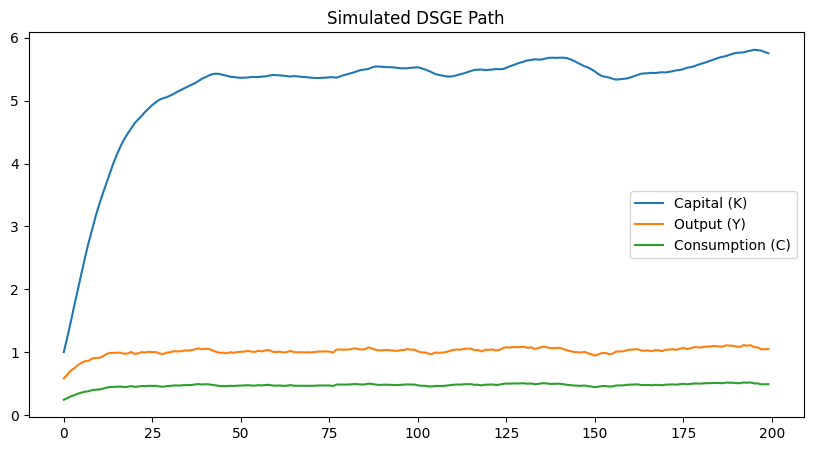

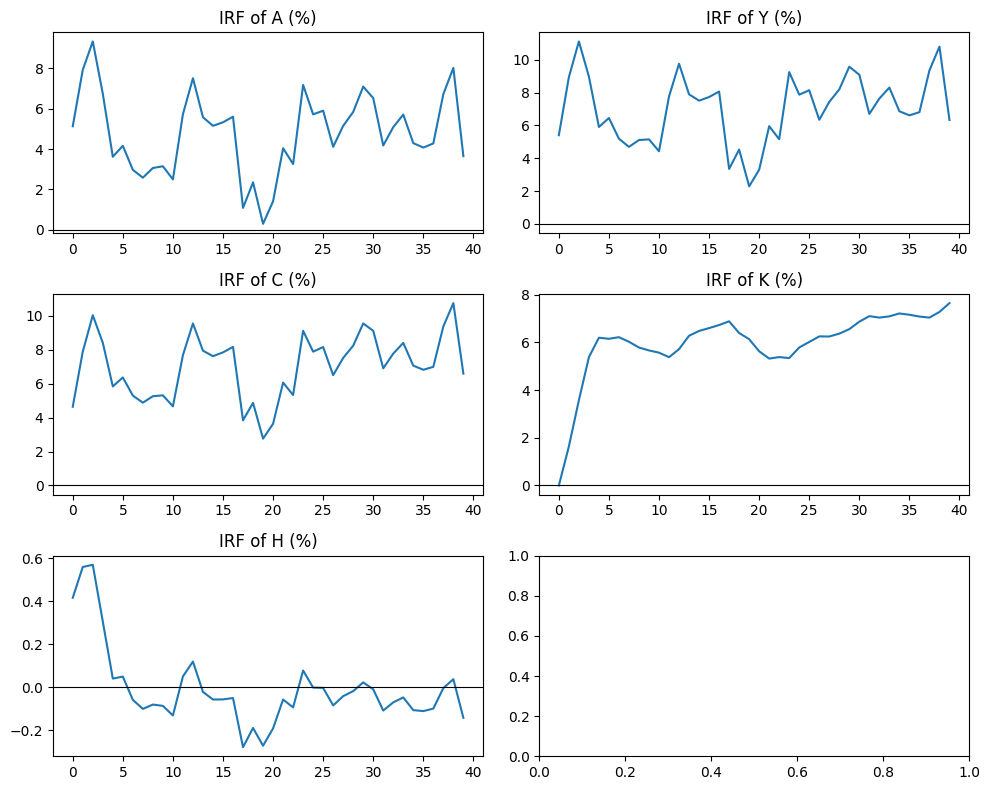

In [124]:
# Creating an untrained model instance
policy_net = DSGE_NN()
model = DSGEModel()

# Simulation
path = model.simulate_path(policy_net, T=200, a0=1.0, k0=1.0, device=device)

plt.figure(figsize=(10,5))
plt.plot(path['K'], label='Capital (K)')
plt.plot(path['Y'], label='Output (Y)')
plt.plot(path['C'], label='Consumption (C)')
plt.legend(); plt.title('Simulated DSGE Path'); plt.show()

# IRFs
irf = model.impulse_response(policy_net, T=40, shock_size=0.05, device=device)

fig, ax = plt.subplots(3, 2, figsize=(10,8))
ax = ax.flatten()
vars_to_plot = ['A', 'Y', 'C', 'K', 'H']

for i, var in enumerate(vars_to_plot):
    ax[i].plot(irf[var].cpu().numpy() * 100)
    ax[i].set_title(f"IRF of {var} (%)")
    ax[i].axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()


Epoch 0: Loss = 1.571899e-03
Epoch 500: Loss = 2.225361e-03
Epoch 1000: Loss = 1.018140e-02
Epoch 1500: Loss = 1.790162e-02
Epoch 2000: Loss = 2.120723e-02
Epoch 2500: Loss = 2.306758e-02
Epoch 3000: Loss = 2.487230e-02
Epoch 3500: Loss = 2.331660e-02
Epoch 4000: Loss = 2.687555e-02
Epoch 4500: Loss = 2.213005e-02
Learning loop completed in 29.27 seconds


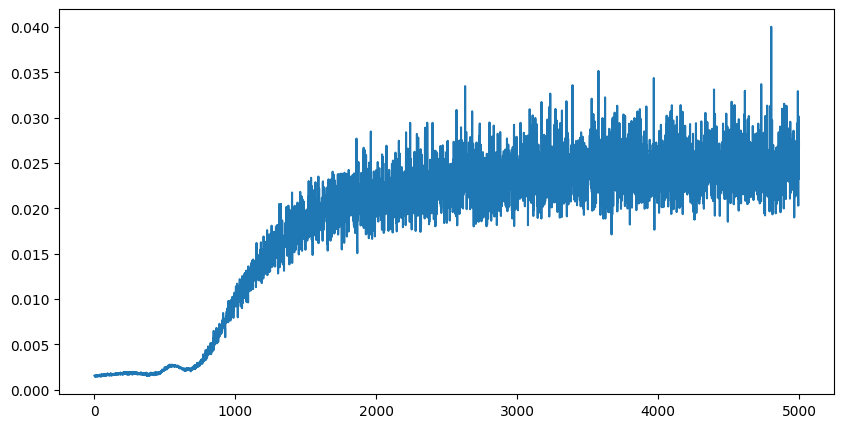

In [131]:
# The training cycle
model = DSGEModel()
policy_net = DSGE_NN().to(device)
optimizer = optim.Adam(policy_net.parameters(), lr=1e-4)
loss_list = []

start_time = time.time()
for epoch in range(5000):
    optimizer.zero_grad()
    loss = euler_residual_loss(model, policy_net, n_samples=1024, device=device)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.item())
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6e}")
end_time = time.time()

print(f"Learning loop completed in {(end_time-start_time):.2f} seconds")
plt.figure(figsize=(10,5))
plt.plot(loss_list)

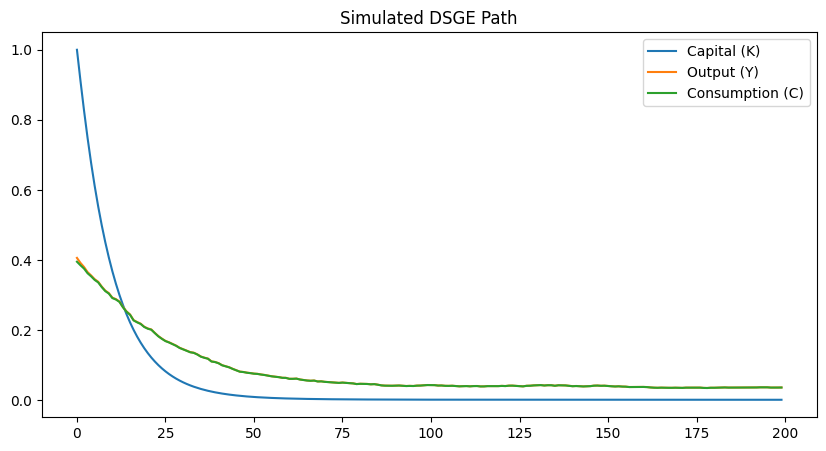

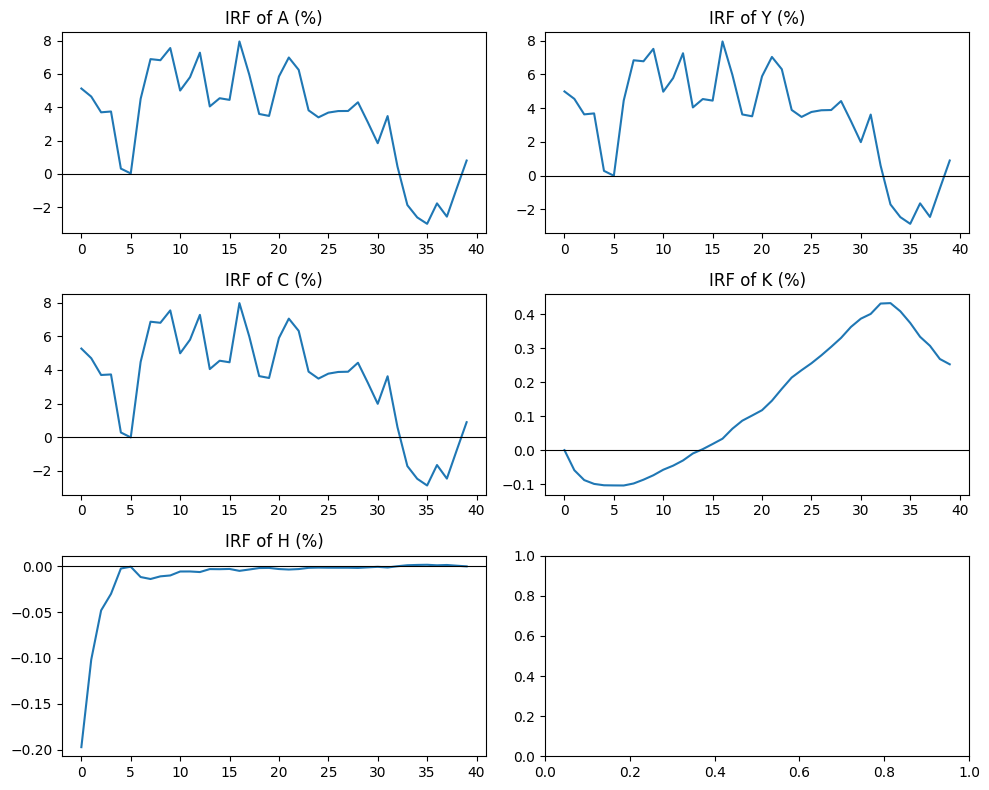

In [132]:
# Simulation
path = model.simulate_path(policy_net, T=200, a0=1.0, k0=1.0, device=device)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(path['K'], label='Capital (K)')
plt.plot(path['Y'], label='Output (Y)')
plt.plot(path['C'], label='Consumption (C)')
plt.legend(); plt.title('Simulated DSGE Path'); plt.show()

# IRFs
irf = model.impulse_response(policy_net, T=40, shock_size=0.05, device=device)

fig, ax = plt.subplots(3, 2, figsize=(10,8))
ax = ax.flatten()
vars_to_plot = ['A', 'Y', 'C', 'K', 'H']

for i, var in enumerate(vars_to_plot):
    ax[i].plot(irf[var].cpu().numpy() * 100)
    ax[i].set_title(f"IRF of {var} (%)")
    ax[i].axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()
